# Generacion de variables de entrada para la Parte 2

In [1]:
def read_vec_file(path):
    polygons = []
    with open(path, "r") as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
        parts = line.split()
        if len(parts) == 2:
            poly_id, n_points = map(int, parts)
            i += 1
            coords = []
            for _ in range(n_points):
                x, y = map(float, lines[i].strip().split())
                coords.append((x, y))
                i += 1
            polygons.append((poly_id, coords))
        else:
            i += 1  # saltar si hay formato raro
    return polygons

polygons = read_vec_file("vegetation.vec")
for pid, coords in polygons:
    print(f"Polygon {pid}: {coords}")


Polygon 1: [(0.0, 0.0), (0.0, 100.0), (100.0, 100.0), (100.0, 0.0)]
Polygon 0: []
Polygon 2: [(20.0, 50.0), (30.0, 60.0), (60.0, 50.0), (60.0, 10.0), (20.0, 10.0)]
Polygon 0: []
Polygon 20: [(30.0, 20.0), (30.0, 25.0), (40.0, 30.0), (50.0, 20.0)]
Polygon 0: []


Polygon 0: 1, Coordinates: [(0.0, 0.0), (0.0, 100.0), (100.0, 100.0), (100.0, 0.0)]
Polygon 1: 0, Coordinates: []
Polygon 1 has no coordinates, skipping...
Polygon 2: 2, Coordinates: [(20.0, 50.0), (30.0, 60.0), (60.0, 50.0), (60.0, 10.0), (20.0, 10.0)]
Polygon 3: 0, Coordinates: []
Polygon 3 has no coordinates, skipping...
Polygon 4: 20, Coordinates: [(30.0, 20.0), (30.0, 25.0), (40.0, 30.0), (50.0, 20.0)]
Polygon 5: 0, Coordinates: []
Polygon 5 has no coordinates, skipping...


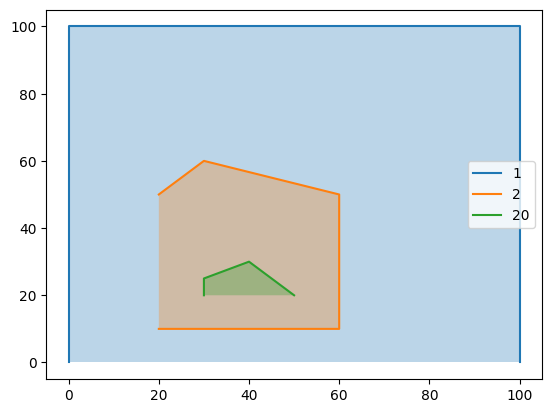

In [2]:
import matplotlib.pyplot as plt

for index, (label, coords) in enumerate(polygons):
    print(f"Polygon {index}: {label}, Coordinates: {coords}")
    if coords:  # Check if coords is not empty
        xs, ys = zip(*coords)
        plt.plot(xs, ys, label=label)
        plt.fill(xs, ys, alpha=0.3)
    else:
        print(f"Polygon {index} has no coordinates, skipping...")

plt.legend()
plt.show()

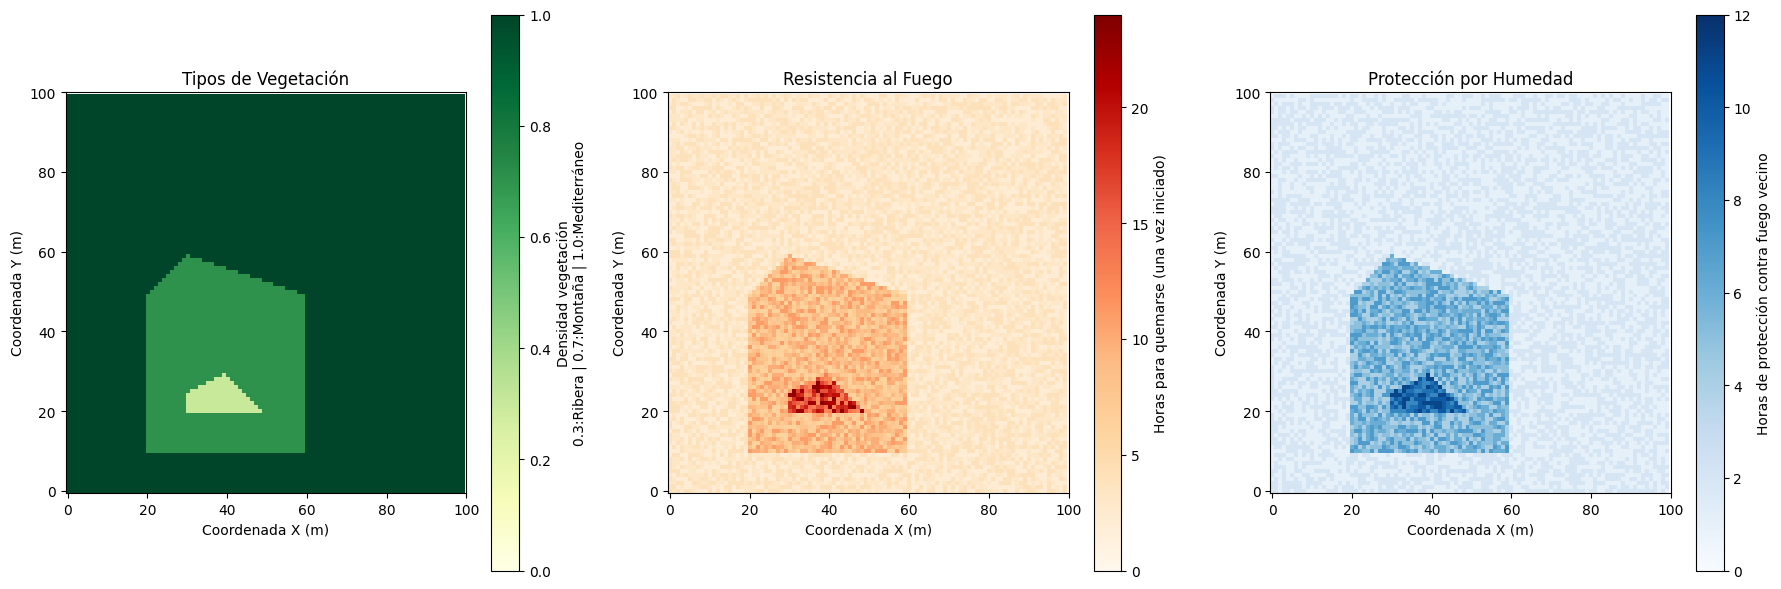

In [3]:
import numpy as np
from shapely.geometry import Point, Polygon

# Configuración del grid
ancho, alto = 100, 100
resolucion = 1

# Definición de polígonos con propiedades actualizadas
poligonos = [
    # (ID, Polígono, Valor_vegetación, Rango_tiempo_quema, Rango_horas_proteccion_humedad)
    (20, Polygon([(30, 20), (30, 25), (40, 30), (50, 20)]), 0.3, (12, 24), (8, 12)),   # Ribera (mayor protección)
    (2, Polygon([(20, 50), (30, 60), (60, 50), (60, 10), (20, 10)]), 0.7, (6, 12), (4, 8)),  # Montaña
    (1, Polygon([(0, 0), (0, 100), (100, 100), (100, 0)]), 1.0, (2, 5), (1, 3))       # Mediterráneo (menor protección)
]

# Inicialización de grids
vegetacion = np.zeros((alto, ancho))          # Densidad de vegetación (0.3, 0.7, 1.0)
tiempo_quema = np.zeros((alto, ancho))        # Horas para quemarse completamente (una vez iniciado)
proteccion_humedad = np.zeros((alto, ancho))  # Horas de protección contra el fuego vecino

# Rellenado de grids
for y in range(alto):
    for x in range(ancho):
        punto = Point(x + 0.5, y + 0.5)
        for _, poly, veg_val, (t_min, t_max), (h_min, h_max) in poligonos:
            if poly.contains(punto):
                vegetacion[y, x] = veg_val
                tiempo_quema[y, x] = int(np.random.uniform(t_min, t_max))
                proteccion_humedad[y, x] = int(np.random.uniform(h_min, h_max))
                break

# Visualización adaptada
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Mapa de vegetación (igual que antes)
im1 = ax1.imshow(vegetacion, cmap='YlGn', origin='lower', vmin=0, vmax=1)
fig.colorbar(im1, ax=ax1, label='Densidad vegetación\n0.3:Ribera | 0.7:Montaña | 1.0:Mediterráneo')
ax1.set_title('Tipos de Vegetación')

# Mapa de tiempo de quema (una vez iniciado el fuego)
im2 = ax2.imshow(tiempo_quema, cmap='OrRd', origin='lower', vmin=0, vmax=24)
fig.colorbar(im2, ax=ax2, label='Horas para quemarse (una vez iniciado)')
ax2.set_title('Resistencia al Fuego')

# Mapa de protección por humedad (nuevo concepto)
im3 = ax3.imshow(proteccion_humedad, cmap='Blues', origin='lower', vmin=0, vmax=12)
fig.colorbar(im3, ax=ax3, label='Horas de protección contra fuego vecino')
ax3.set_title('Protección por Humedad')

# Ajustes comunes
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('Coordenada X (m)')
    ax.set_ylabel('Coordenada Y (m)')
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_yticks(np.arange(0, 101, 20))

plt.tight_layout()
plt.show()

In [ ]:
# Dimensiones (consistentes con tus grids anteriores)
ancho, alto = 100, 100

# Crear grid de estados (inicializado como "SANO" = 0)
#NO_QUEMADO = 0
#QUEMANDOSE = 1
#QUEMADO = 2
estado_vegetacion = np.full((alto, ancho), 0)

In [5]:
print(estado_vegetacion, tiempo_quema, proteccion_humedad)


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] [[4. 3. 4. ... 3. 2. 4.]
 [4. 4. 2. ... 3. 2. 4.]
 [3. 3. 4. ... 2. 2. 2.]
 ...
 [3. 4. 3. ... 3. 3. 4.]
 [2. 4. 3. ... 3. 3. 3.]
 [3. 3. 4. ... 2. 2. 3.]] [[2. 2. 1. ... 1. 2. 1.]
 [2. 2. 1. ... 1. 1. 2.]
 [2. 2. 1. ... 1. 2. 2.]
 ...
 [1. 2. 1. ... 2. 1. 1.]
 [2. 1. 1. ... 1. 2. 2.]
 [1. 2. 2. ... 2. 1. 1.]]


In [9]:
# 1. Obtener coordenadas de todas las celdas sanas
celdas_sanas = np.argwhere(estado_vegetacion == 0)
np.random.seed(42)
# 2. Seleccionar una celda aleatoria
if len(celdas_sanas) > 0:
    y, x = celdas_sanas[np.random.randint(0, len(celdas_sanas))]
    print(f"Celda seleccionada: ({x}, {y})")
else:
    print("No hay celdas SANAS disponibles")

Celda seleccionada: (70, 72)


In [10]:
estado_vegetacion[70][72] = 1
proteccion_humedad[70][72] = 0

In [ ]:
# Crear el contenido del archivo Python
with open('datos_simulacion.py', 'w') as f:
    f.write("import numpy as np\n\n")
    
    # Escribir el primer array
    f.write("estado_vegetacion = np.array([\n")
    for fila in estado_vegetacion:
        f.write(f"    {fila.tolist()},\n")
    f.write("])\n\n")
    
    # Escribir el segundo array
    f.write("tiempo_quema = np.array([\n")
    for fila in tiempo_quema:
        f.write(f"    {fila.tolist()},\n")
    f.write("])\n\n")
    
    # Escribir el tercer array
    f.write("proteccion_humedad = np.array([\n")
    for fila in proteccion_humedad:
        f.write(f"    {fila.tolist()},\n")
    f.write("])\n")